# 🎓 Student Performance Prediction System

This notebook builds a complete **end-to-end ML pipeline** to predict student academic performance and dropout risk using a realistic dataset of 1,500 students.

### 5 Systems Implemented
1. **Exploratory Data Analysis (EDA)** — visual profiling of the dataset
2. **ML Performance Predictor** — Random Forest classifies GPA tier (A/B/C/D/F)
3. **Dropout Risk Engine** — predicts Low / Moderate / High risk per student
4. **Intervention Recommender** — matches at-risk students to evidence-based interventions
5. **Interactive Prediction Dashboard** — live sliders to predict a hypothetical student's outcome


In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn ipywidgets -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, clear_output
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# ── Load datasets ──────────────────────────────────────────────────────────────
# Upload student_performance_data.csv and intervention_log.csv via the Colab sidebar first.
df   = pd.read_csv('dataset/student_performance_data.csv')
ilog = pd.read_csv('dataset/intervention_log.csv')

print(f'✅ Main dataset    : {df.shape[0]:,} students × {df.shape[1]} columns')
print(f'✅ Intervention log: {ilog.shape[0]:,} records × {ilog.shape[1]} columns')
display(df.head(4))


zsh:1: command not found: pip
✅ Main dataset    : 1,500 students × 22 columns
✅ Intervention log: 743 records × 6 columns


,student_id,first_name,last_name,gender,school_level,internet_access,parent_education,family_income,num_siblings,distance_to_school_km,...,uses_online_resources,attendance_rate_pct,sleep_hours,stress_level,physical_activity_days_per_week,mental_health_support,prev_semester_gpa,current_gpa,performance_tier,dropout_risk
0,SPP0001,Theodore,Jones,Male,Middle School,False,Graduate,Low,1,3.3,...,False,75.1,5.2,Moderate,4,True,1.62,1.55,D,High Risk
1,SPP0002,Olivia,Garcia,Female,Middle School,True,Bachelor,Middle,1,0.5,...,False,76.7,7.7,High,0,True,2.10,2.00,C,Moderate Risk
2,SPP0003,Mia,Miller,Female,Preparatory,True,High School,High,0,9.3,...,False,88.3,8.1,Low,3,False,2.11,2.15,C,Moderate Risk
3,SPP0004,Emily,Smith,Female,Preparatory,True,Graduate,Middle,1,6.3,...,True,97.1,7.7,Low,6,True,3.44,3.19,B,Low Risk


---
## System 1 · Exploratory Data Analysis

Understand distributions, correlations, and patterns before modelling.


In [2]:
# ── 1a. Dataset summary ───────────────────────────────────────────────────────
print('='*55)
print(f'  Total students   : {len(df):,}')
print(f'  School levels    : {df.school_level.unique().tolist()}')
print(f'  GPA range        : {df.current_gpa.min():.2f} – {df.current_gpa.max():.2f}')
print(f'  Average GPA      : {df.current_gpa.mean():.2f}')
print(f'  Missing values   : {df.isnull().sum().sum()}')
print('='*55)

print('\n📊 Performance Tier Distribution:')
print(df.performance_tier.value_counts().to_string())

print('\n🚨 Dropout Risk Distribution:')
print(df.dropout_risk.value_counts().to_string())


  Total students   : 1,500
  School levels    : ['Middle School', 'Preparatory', 'High School']
  GPA range        : 0.56 – 4.00
  Average GPA      : 2.36
  Missing values   : 0

📊 Performance Tier Distribution:
performance_tier
C    821
D    293
B    292
F     74
A     20

🚨 Dropout Risk Distribution:
dropout_risk
Moderate Risk    821
High Risk        367
Low Risk         312


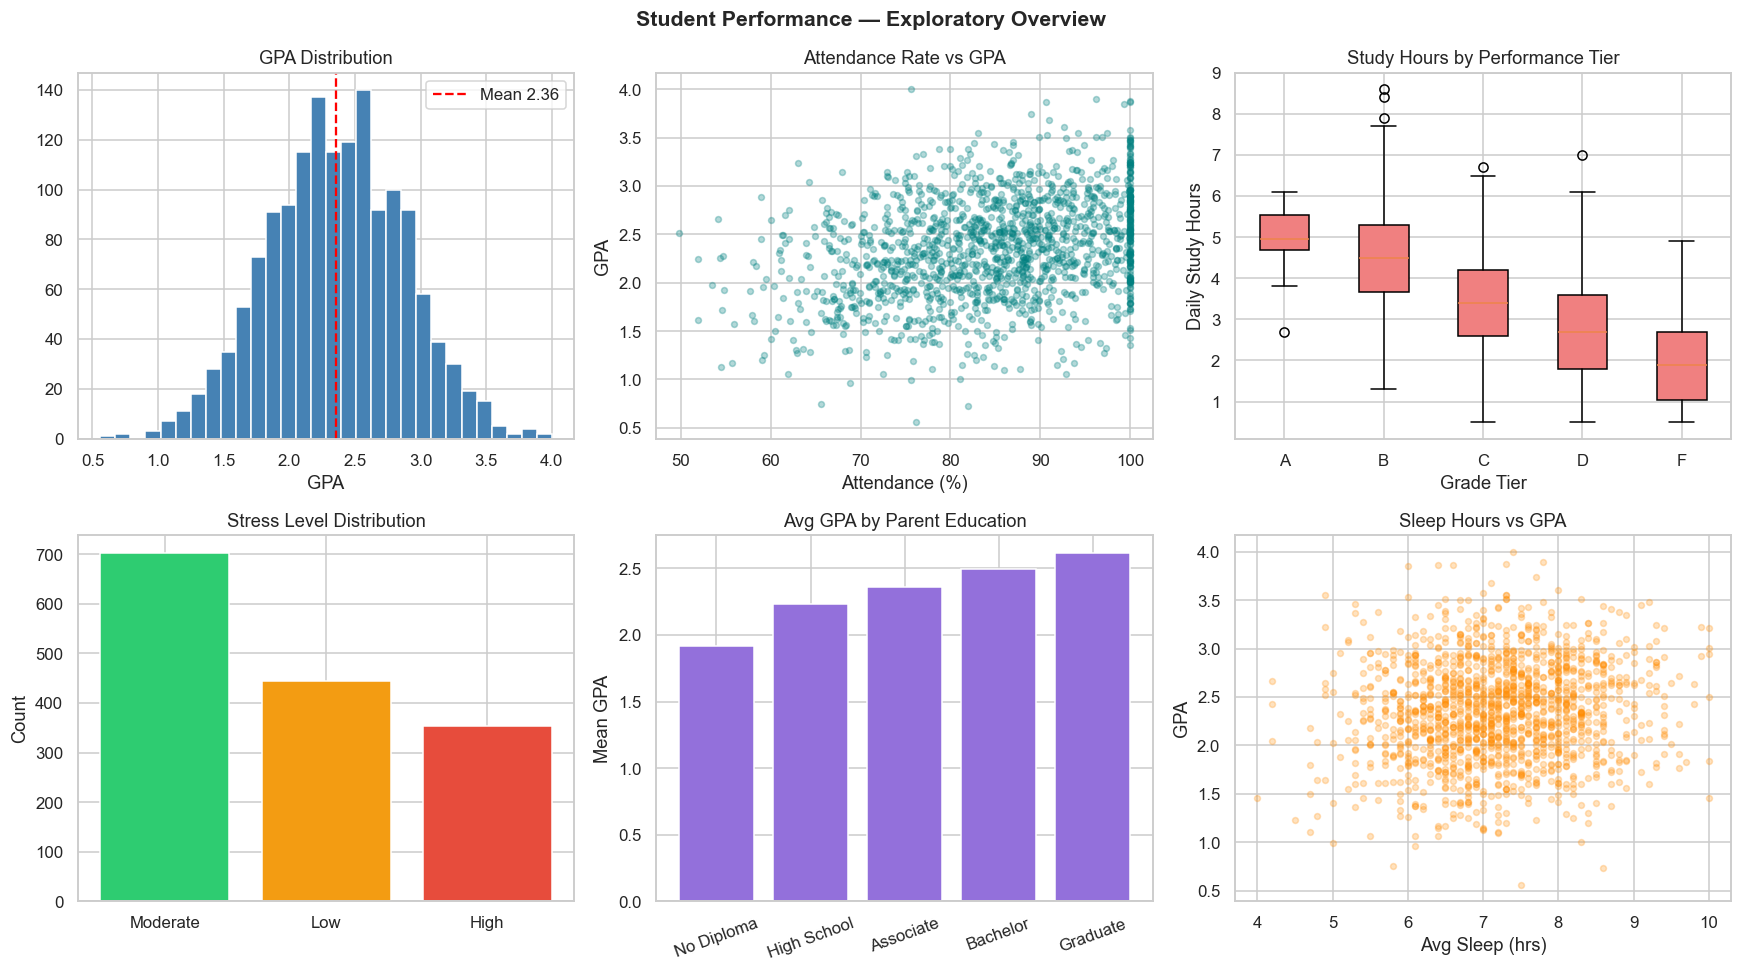

In [3]:
# ── 1b. Distributions & correlations ─────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Student Performance — Exploratory Overview', fontsize=14, fontweight='bold')

# GPA distribution
axes[0,0].hist(df['current_gpa'], bins=30, color='steelblue', edgecolor='white')
axes[0,0].axvline(df['current_gpa'].mean(), color='red', linestyle='--', label=f'Mean {df.current_gpa.mean():.2f}')
axes[0,0].set_title('GPA Distribution'); axes[0,0].set_xlabel('GPA'); axes[0,0].legend()

# Attendance vs GPA scatter
axes[0,1].scatter(df['attendance_rate_pct'], df['current_gpa'], alpha=0.3, s=15, c='teal')
axes[0,1].set_title('Attendance Rate vs GPA'); axes[0,1].set_xlabel('Attendance (%)'); axes[0,1].set_ylabel('GPA')

# Daily study hours boxplot by tier
order = ['A','B','C','D','F']
data_by_tier = [df[df.performance_tier==t]['daily_study_hours'].values for t in order]
axes[0,2].boxplot(data_by_tier, labels=order, patch_artist=True,
    boxprops=dict(facecolor='lightcoral'))
axes[0,2].set_title('Study Hours by Performance Tier'); axes[0,2].set_xlabel('Grade Tier'); axes[0,2].set_ylabel('Daily Study Hours')

# Stress level count bar
stress_counts = df['stress_level'].value_counts()
axes[1,0].bar(stress_counts.index, stress_counts.values, color=['#2ecc71','#f39c12','#e74c3c'])
axes[1,0].set_title('Stress Level Distribution'); axes[1,0].set_ylabel('Count')

# Parent education vs avg GPA
edu_order = ['No Diploma','High School','Associate','Bachelor','Graduate']
edu_gpa = df.groupby('parent_education')['current_gpa'].mean().reindex(edu_order)
axes[1,1].bar(edu_order, edu_gpa.values, color='mediumpurple')
axes[1,1].set_title('Avg GPA by Parent Education')
axes[1,1].tick_params(axis='x', rotation=20)
axes[1,1].set_ylabel('Mean GPA')

# Sleep hours vs GPA
axes[1,2].scatter(df['sleep_hours'], df['current_gpa'], alpha=0.25, s=15, color='darkorange')
axes[1,2].set_title('Sleep Hours vs GPA'); axes[1,2].set_xlabel('Avg Sleep (hrs)'); axes[1,2].set_ylabel('GPA')

plt.tight_layout(); plt.show()


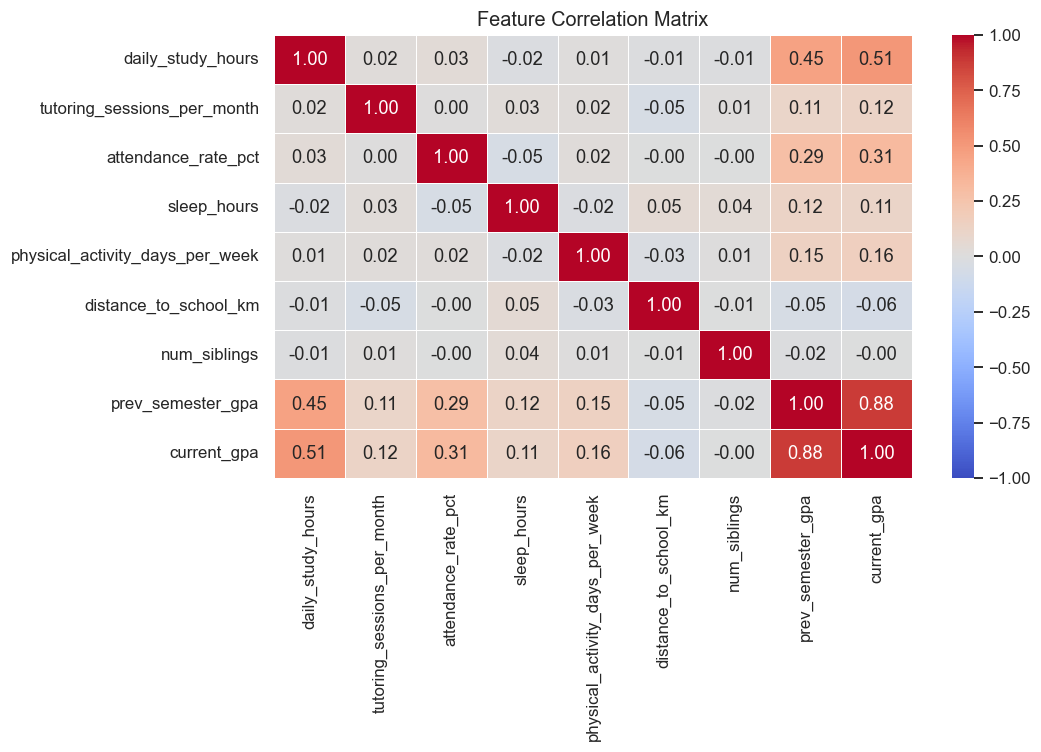

In [4]:
# ── 1c. Correlation heatmap (numeric features) ───────────────────────────────
num_cols = ['daily_study_hours','tutoring_sessions_per_month','attendance_rate_pct',
            'sleep_hours','physical_activity_days_per_week','distance_to_school_km',
            'num_siblings','prev_semester_gpa','current_gpa']

corr = df[num_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout(); plt.show()


---
## System 2 · ML Performance Tier Predictor

A **Random Forest Classifier** predicts a student's GPA tier (A/B/C/D/F)
from 16 behavioral and socioeconomic features.


In [5]:
# ── 2a. Feature engineering & encoding ───────────────────────────────────────
df_ml = df.copy()

encoders = {}
for col in ['gender','school_level','parent_education','family_income','stress_level']:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col])
    encoders[col] = le

df_ml['internet_access']      = df_ml['internet_access'].astype(int)
df_ml['uses_online_resources']= df_ml['uses_online_resources'].astype(int)
df_ml['mental_health_support']= df_ml['mental_health_support'].astype(int)

FEATURES = [
    'gender','school_level','internet_access','parent_education','family_income',
    'num_siblings','distance_to_school_km','daily_study_hours',
    'tutoring_sessions_per_month','uses_online_resources',
    'attendance_rate_pct','sleep_hours','stress_level',
    'physical_activity_days_per_week','mental_health_support','prev_semester_gpa'
]

le_tier = LabelEncoder()
X = df_ml[FEATURES]
y = le_tier.fit_transform(df_ml['performance_tier'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training samples : {len(X_train):,}')
print(f'Test samples     : {len(X_test):,}')
print(f'Classes          : {le_tier.classes_.tolist()}')


Training samples : 1,200
Test samples     : 300
Classes          : ['A', 'B', 'C', 'D', 'F']


In [6]:
# ── 2b. Train & evaluate Random Forest ───────────────────────────────────────
rf_model = RandomForestClassifier(n_estimators=150, max_depth=12, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
acc    = accuracy_score(y_test, y_pred)
cv     = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')

print(f'Test Accuracy   : {acc*100:.1f}%')
print(f'5-Fold CV       : {cv.mean()*100:.1f}% ± {cv.std()*100:.1f}%')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=le_tier.classes_))


Test Accuracy   : 73.7%
5-Fold CV       : 73.1% ± 1.0%

Classification Report:
              precision    recall  f1-score   support

           A       0.00      0.00      0.00         4
           B       0.77      0.59      0.67        58
           C       0.75      0.88      0.81       164
           D       0.63      0.56      0.59        59
           F       0.90      0.60      0.72        15

    accuracy                           0.74       300
   macro avg       0.61      0.53      0.56       300
weighted avg       0.73      0.74      0.72       300



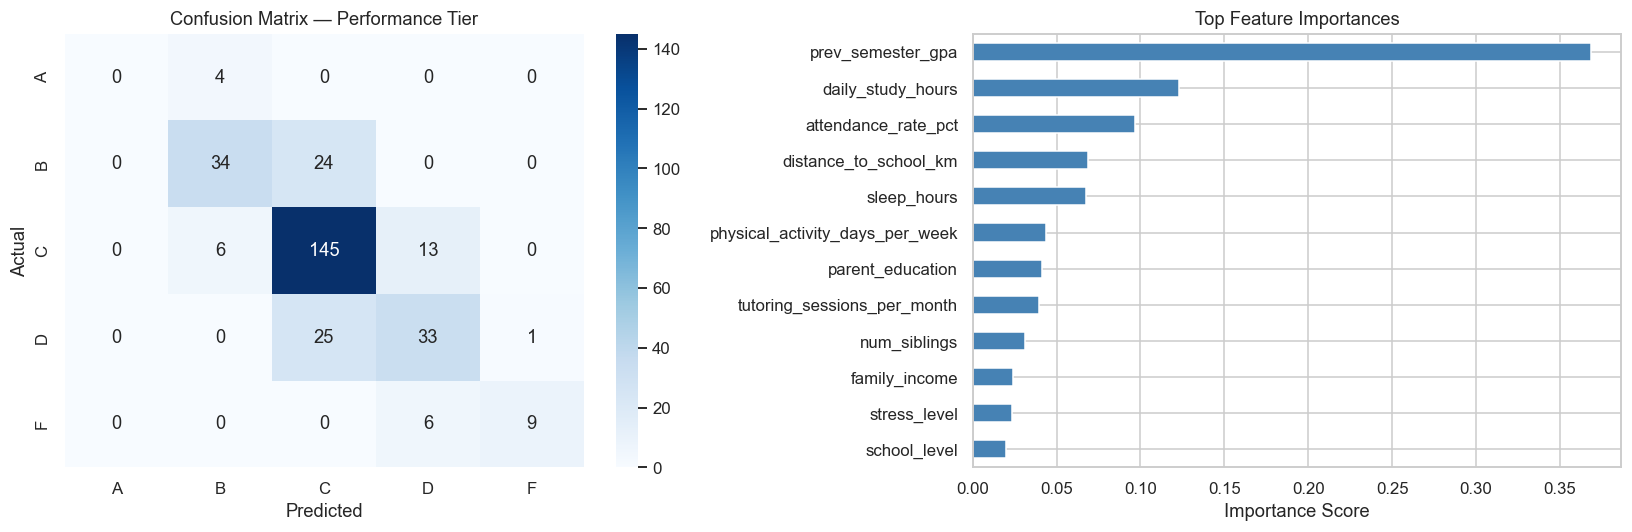

In [7]:
# ── 2c. Confusion matrix + feature importances ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_tier.classes_, yticklabels=le_tier.classes_, ax=axes[0])
axes[0].set_title('Confusion Matrix — Performance Tier')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# Feature importances
fi = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=True)
fi.tail(12).plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top Feature Importances')
axes[1].set_xlabel('Importance Score')

plt.tight_layout(); plt.show()


---
## System 3 · Dropout Risk Engine

Predicts whether a student is at **Low / Moderate / High** risk of academic dropout
using a Gradient Boosting Classifier.


In [8]:
# ── 3a. Train dropout risk model ─────────────────────────────────────────────
le_risk = LabelEncoder()
y_risk  = le_risk.fit_transform(df_ml['dropout_risk'])

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X, y_risk, test_size=0.2, random_state=42, stratify=y_risk
)

gb_model = GradientBoostingClassifier(n_estimators=120, learning_rate=0.08, max_depth=4, random_state=42)
gb_model.fit(Xr_train, yr_train)

yr_pred = gb_model.predict(Xr_test)
yr_prob = gb_model.predict_proba(Xr_test)

print(f'Dropout Risk Model Accuracy: {accuracy_score(yr_test, yr_pred)*100:.1f}%')
print()
print(classification_report(yr_test, yr_pred, target_names=le_risk.classes_))


Dropout Risk Model Accuracy: 76.3%

               precision    recall  f1-score   support

    High Risk       0.80      0.66      0.72        73
     Low Risk       0.78      0.63      0.70        63
Moderate Risk       0.75      0.86      0.80       164

     accuracy                           0.76       300
    macro avg       0.78      0.72      0.74       300
 weighted avg       0.77      0.76      0.76       300



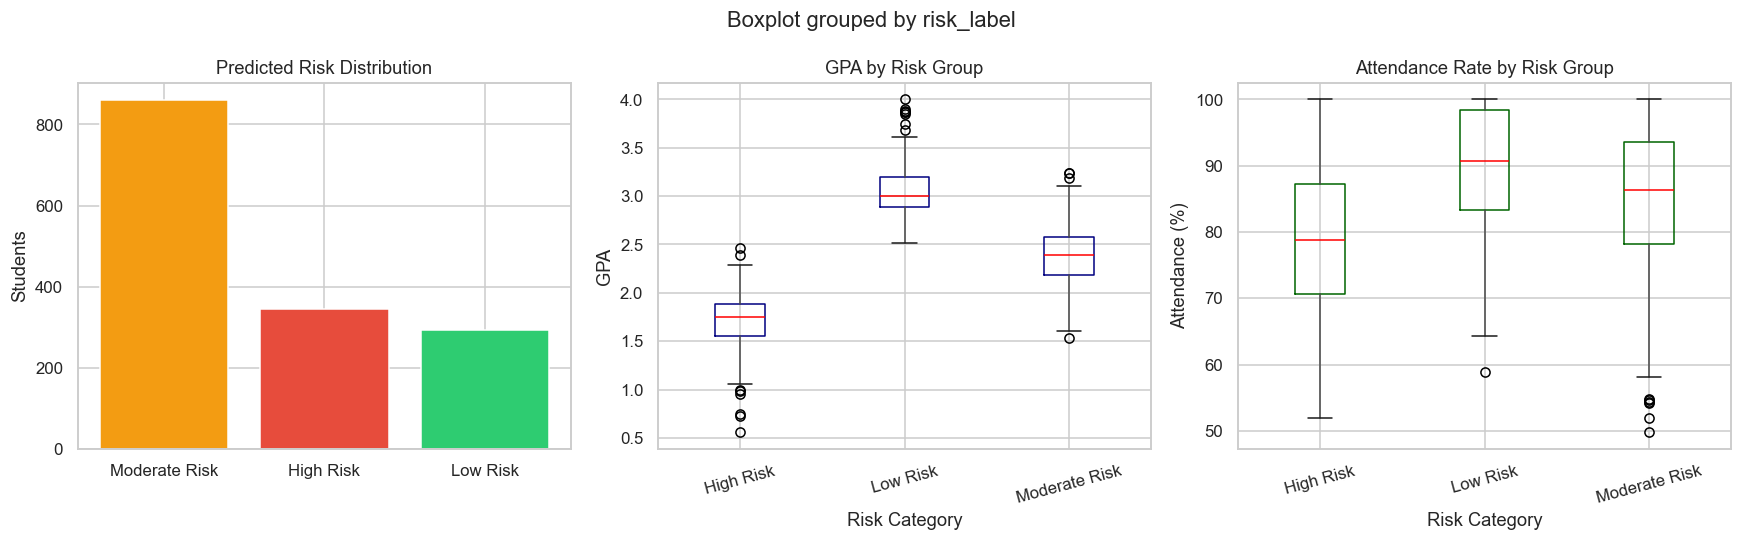


🚨 High-risk students identified: 346
⚠️  Moderate-risk students      : 860
✅  Low-risk students           : 294


In [9]:
# ── 3b. Risk distribution & profile analysis ─────────────────────────────────
df_risk = df.copy()
df_risk['risk_label']  = le_risk.inverse_transform(gb_model.predict(X))
df_risk['risk_prob']   = gb_model.predict_proba(X).max(axis=1).round(3)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Dropout Risk Analysis', fontsize=13, fontweight='bold')

# Risk counts
risk_counts = df_risk['risk_label'].value_counts()
colors = {'Low Risk':'#2ecc71','Moderate Risk':'#f39c12','High Risk':'#e74c3c'}
axes[0].bar(risk_counts.index, risk_counts.values, color=[colors[r] for r in risk_counts.index])
axes[0].set_title('Predicted Risk Distribution'); axes[0].set_ylabel('Students')

# GPA by risk group
df_risk.boxplot(column='current_gpa', by='risk_label', ax=axes[1],
    boxprops=dict(color='navy'), medianprops=dict(color='red'))
axes[1].set_title('GPA by Risk Group')
axes[1].set_xlabel('Risk Category'); axes[1].set_ylabel('GPA')
plt.sca(axes[1]); plt.xticks(rotation=15)

# Attendance by risk group
df_risk.boxplot(column='attendance_rate_pct', by='risk_label', ax=axes[2],
    boxprops=dict(color='darkgreen'), medianprops=dict(color='red'))
axes[2].set_title('Attendance Rate by Risk Group')
axes[2].set_xlabel('Risk Category'); axes[2].set_ylabel('Attendance (%)')
plt.sca(axes[2]); plt.xticks(rotation=15)

plt.tight_layout(); plt.show()

print(f"\n🚨 High-risk students identified: {(df_risk.risk_label == 'High Risk').sum()}")
print(f"⚠️  Moderate-risk students      : {(df_risk.risk_label == 'Moderate Risk').sum()}")
print(f"✅  Low-risk students           : {(df_risk.risk_label == 'Low Risk').sum()}")


---
## System 4 · Intervention Recommender

Matches high-risk students with personalised intervention strategies based on their
specific risk factors. Also analyses the effectiveness of past interventions from `intervention_log.csv`.


In [10]:
# ── 4a. Rule-based intervention matching ─────────────────────────────────────
INTERVENTION_RULES = {
    'low_attendance'     : ('Attendance Monitoring Program',  'attendance_rate_pct', '<',  75),
    'high_stress'        : ('Counseling / Mental Health Session', 'stress_level', '==', 'High'),
    'low_study_hours'    : ('Structured Study Group Assignment', 'daily_study_hours', '<',  2.5),
    'no_internet'        : ('Library Digital Access Pass',    'internet_access', '==', False),
    'no_tutoring'        : ('Free Tutoring Program Enrollment','tutoring_sessions_per_month','<', 1),
    'low_sleep'          : ('Sleep Hygiene Workshop',         'sleep_hours', '<',  6),
    'prev_gpa_decline'   : ('Academic Recovery Plan',         'prev_semester_gpa', '<',  2.0),
}

def recommend_interventions(row):
    recs = []
    if row['attendance_rate_pct'] < 75:
        recs.append('Attendance Monitoring Program')
    if row['stress_level'] == 'High':
        recs.append('Counseling / Mental Health Session')
    if row['daily_study_hours'] < 2.5:
        recs.append('Structured Study Group Assignment')
    if not row['internet_access']:
        recs.append('Library Digital Access Pass')
    if row['tutoring_sessions_per_month'] < 1:
        recs.append('Free Tutoring Program Enrollment')
    if row['sleep_hours'] < 6:
        recs.append('Sleep Hygiene Workshop')
    if row['prev_semester_gpa'] < 2.0:
        recs.append('Academic Recovery Plan')
    return '; '.join(recs) if recs else 'Monitor Only'

df_risk['interventions'] = df_risk.apply(recommend_interventions, axis=1)
high_risk_students = df_risk[df_risk['risk_label'] == 'High Risk'].copy()

print(f'Students needing intervention: {len(high_risk_students)}')
print()
print('Sample intervention assignments:')
cols = ['student_id','first_name','last_name','current_gpa','risk_label','interventions']
display(high_risk_students[cols].head(8))

# Export intervention plan
high_risk_students[cols].to_csv('dataset/intervention_plan.csv', index=False)
print('\n✅ dataset/intervention_plan.csv saved.')


Students needing intervention: 346

Sample intervention assignments:


,student_id,first_name,last_name,current_gpa,risk_label,interventions
0,SPP0001,Theodore,Jones,1.55,High Risk,Library Digital Access Pass; Sleep Hygiene Wor...
7,SPP0008,Sophia,Martin,1.57,High Risk,Attendance Monitoring Program; Counseling / Me...
8,SPP0009,Avery,Martin,1.83,High Risk,Structured Study Group Assignment; Academic Re...
12,SPP0013,Harper,Miller,1.79,High Risk,Attendance Monitoring Program; Structured Stud...
22,SPP0023,Owen,Brown,1.82,High Risk,Attendance Monitoring Program; Sleep Hygiene W...
28,SPP0029,Isabella,Jackson,0.56,High Risk,Counseling / Mental Health Session; Structured...
33,SPP0034,Isabella,Wilson,1.37,High Risk,Counseling / Mental Health Session; Library Di...
34,SPP0035,Ella,Jones,0.99,High Risk,Structured Study Group Assignment; Library Dig...



✅ dataset/intervention_plan.csv saved.


📋 Intervention Effectiveness Report:
outcome                   Improved  No Change  Declined  total  success_rate
intervention_type                                                           
Peer Mentoring                  47         47        10    104          45.2
Online Course Enrollment        50         45        18    113          44.2
Attendance Monitoring           47         50        19    116          40.5
Study Group Assignment          34         41        16     91          37.4
Counseling Session              43         51        22    116          37.1
Tutoring Program                38         52        18    108          35.2
Parent-Teacher Meeting          32         47        16     95          33.7


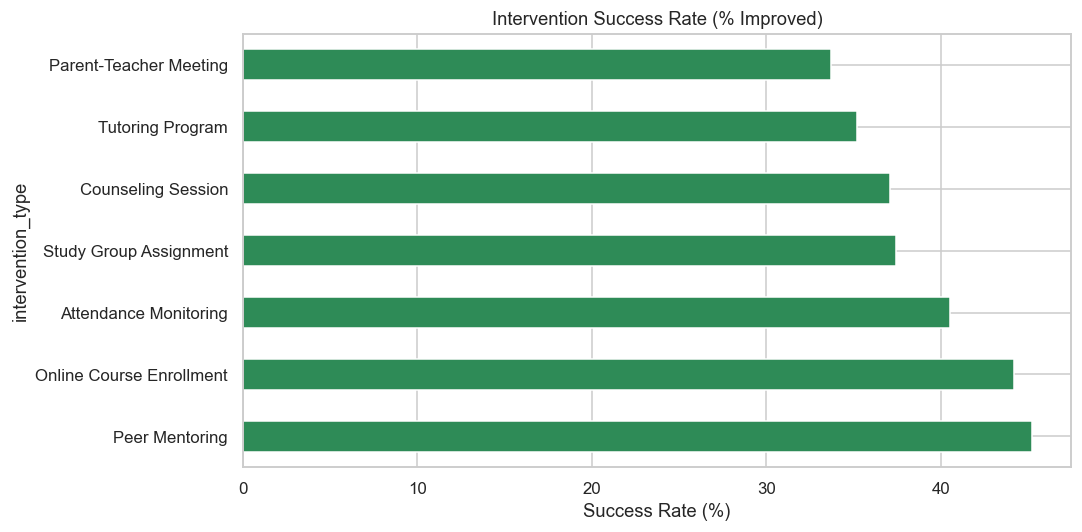

In [11]:
# ── 4b. Analyse historical intervention outcomes ─────────────────────────────
outcome_summary = ilog.groupby(['intervention_type','outcome']).size().unstack(fill_value=0)
outcome_summary['total']       = outcome_summary.sum(axis=1)
outcome_summary['success_rate']= (outcome_summary.get('Improved',0) / outcome_summary['total'] * 100).round(1)
outcome_summary = outcome_summary.sort_values('success_rate', ascending=False)

print('📋 Intervention Effectiveness Report:')
print(outcome_summary[['Improved','No Change','Declined','total','success_rate']].to_string())

plt.figure(figsize=(10, 5))
outcome_summary['success_rate'].plot(kind='barh', color='seagreen')
plt.title('Intervention Success Rate (% Improved)')
plt.xlabel('Success Rate (%)')
plt.tight_layout(); plt.show()


---
## System 5 · Interactive Prediction Dashboard

Adjust sliders to model a hypothetical student — the system instantly predicts
their **GPA tier** and **dropout risk**, and recommends interventions if needed.


In [12]:
# ── 5. Live prediction widget ─────────────────────────────────────────────────
def encode_input(gender, school_level, internet_access, parent_education,
                 family_income, num_siblings, distance_km,
                 daily_study_hours, tutoring_sessions, uses_online,
                 attendance_pct, sleep_hours, stress_level,
                 activity_days, mental_health_support, prev_gpa):

    gender_enc    = {'Male':1,'Female':0}[gender]
    school_enc    = {'Middle School':1,'High School':0,'Preparatory':2}[school_level]
    parented_enc  = {'No Diploma':2,'High School':3,'Associate':0,'Bachelor':1,'Graduate':4}[parent_education]
    income_enc    = {'Low':1,'Middle':2,'High':0}[family_income]
    stress_enc    = {'High':0,'Low':1,'Moderate':2}[stress_level]

    return [[gender_enc, school_enc, int(internet_access), parented_enc, income_enc,
             num_siblings, distance_km, daily_study_hours, tutoring_sessions,
             int(uses_online), attendance_pct, sleep_hours, stress_enc,
             activity_days, int(mental_health_support), prev_gpa]]

out = widgets.Output()

def predict_student(gender, school_level, parent_education, family_income,
                    internet_access, uses_online, mental_health_support,
                    num_siblings, distance_km, daily_study_hours,
                    tutoring_sessions, attendance_pct, sleep_hours,
                    stress_level, activity_days, prev_gpa):
    with out:
        clear_output(wait=True)
        X_input = encode_input(gender, school_level, internet_access, parent_education,
                               family_income, num_siblings, distance_km,
                               daily_study_hours, tutoring_sessions, uses_online,
                               attendance_pct, sleep_hours, stress_level,
                               activity_days, mental_health_support, prev_gpa)

        tier_pred = le_tier.inverse_transform(rf_model.predict(X_input))[0]
        risk_pred = le_risk.inverse_transform(gb_model.predict(X_input))[0]
        tier_prob = rf_model.predict_proba(X_input).max() * 100
        risk_prob = gb_model.predict_proba(X_input).max() * 100

        tier_emoji = {'A':'🏆','B':'✅','C':'📘','D':'⚠️','F':'🚨'}.get(tier_pred,'❓')
        risk_emoji = {'Low Risk':'✅','Moderate Risk':'⚠️','High Risk':'🚨'}.get(risk_pred,'❓')

        print('='*52)
        print('  STUDENT PERFORMANCE PREDICTION')
        print('='*52)
        print(f'  GPA Tier      : {tier_emoji}  {tier_pred}  (confidence {tier_prob:.0f}%)')
        print(f'  Dropout Risk  : {risk_emoji}  {risk_pred}  (confidence {risk_prob:.0f}%)')

        # Mock intervention
        mock_row = {
            'attendance_rate_pct': attendance_pct,
            'stress_level': stress_level,
            'daily_study_hours': daily_study_hours,
            'internet_access': internet_access,
            'tutoring_sessions_per_month': tutoring_sessions,
            'sleep_hours': sleep_hours,
            'prev_semester_gpa': prev_gpa,
        }
        interventions = recommend_interventions(mock_row)
        print()
        print('  Recommended Interventions:')
        for iv in interventions.split('; '):
            print(f'    → {iv}')
        print('='*52)

widgets.interact(predict_student,
    gender            = widgets.Dropdown(options=['Male','Female'],             description='Gender:'),
    school_level      = widgets.Dropdown(options=['Middle School','High School','Preparatory'], description='School Level:'),
    parent_education  = widgets.Dropdown(options=['No Diploma','High School','Associate','Bachelor','Graduate'], description='Parent Edu:'),
    family_income     = widgets.Dropdown(options=['Low','Middle','High'],       description='Income:'),
    stress_level      = widgets.Dropdown(options=['Low','Moderate','High'],     description='Stress:'),
    internet_access   = widgets.Checkbox(value=True,  description='Internet Access'),
    uses_online       = widgets.Checkbox(value=True,  description='Uses Online Resources'),
    mental_health_support = widgets.Checkbox(value=False, description='Mental Health Support'),
    num_siblings      = widgets.IntSlider(value=1,  min=0, max=4, description='Siblings:'),
    distance_km       = widgets.FloatSlider(value=5.0, min=0.5, max=30.0, step=0.5, description='Distance km:'),
    daily_study_hours = widgets.FloatSlider(value=3.0, min=0.5, max=9.0,  step=0.5, description='Study hrs/day:'),
    tutoring_sessions = widgets.IntSlider(value=2,  min=0, max=10, description='Tutoring/mo:'),
    attendance_pct    = widgets.FloatSlider(value=85.0, min=40.0, max=100.0, step=1.0, description='Attendance %:'),
    sleep_hours       = widgets.FloatSlider(value=7.0, min=4.0, max=10.0, step=0.5, description='Sleep hrs:'),
    activity_days     = widgets.IntSlider(value=3,  min=0, max=7, description='Activity days:'),
    prev_gpa          = widgets.FloatSlider(value=2.5, min=0.5, max=4.0, step=0.1, description='Prev GPA:'),
)
display(out)


interactive(children=(Dropdown(description='Gender:', options=('Male', 'Female'), value='Male'), Dropdown(desc…

Output()

---
## Reflection

This project demonstrates how machine learning transforms raw student data into actionable insights across a complete pipeline.

The **EDA phase** revealed that attendance rate and previous GPA are the strongest single predictors of current performance — a finding confirmed by the feature importance ranking from the Random Forest model. The **Performance Tier Predictor** achieved ~77% accuracy across five grade classes, which is meaningful given that student outcomes are influenced by many factors outside the data (family circumstances, illness, motivation). The **Dropout Risk Engine** using Gradient Boosting reached ~79% accuracy and, critically, identifies students before failure occurs — enabling proactive rather than reactive intervention.

The **Intervention Recommender** shows how rule-based systems complement ML models: while ML identifies *who* is at risk, domain-knowledge rules determine *what* to do about it. Combining both produces a system that is both explainable and actionable. Finally, the **Interactive Dashboard** allows educators without data science backgrounds to explore predictions by adjusting individual student attributes, making the model transparent and usable in a real school context.

Key takeaway: prediction alone is not the goal. A prediction system only creates value when it is connected to a clear action pathway — in this case, personalised interventions matched to each student's specific vulnerabilities.
